# BetterGruRnnlm

这个 notebook 用来基于 `my-torch-lib` 手动训练 GRU 版改进语言模型 `BetterGruRnnlm`。

相较于 `Rnnlm`，这一版 GRU 模型沿用 BetterRnnlm 的三点改进：

- 两层 `TimeGRU`
- 深度方向上的 `TimeDropout`
- `TimeEmbedding` 和输出 `TimeLinear` 的权重共享

注意：`BetterGruRnnlm.forward(xs)` 只返回 logits，loss 仍然在模型外部单独计算。


## 环境准备：说明

这一步的目标是把 notebook 运行环境接到 `deep_learning_implementation`、`my-torch-lib` 和 `my-eval-lib`。

后面会用到 PTB 数据、`BetterGruRnnlm`、时间版损失层、SGD、梯度裁剪、连续语料 batch helper 和困惑度函数。


In [1]:
from pathlib import Path
import time
import sys
import random
import torch
import numpy as np

projects_dir = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(".."))
sys.path.insert(0, str(projects_dir / "my-torch-lib"))
sys.path.insert(0, str(projects_dir / "my-eval-lib"))

from dataset import ptb
from torchlib.models.rnnlm import BetterGruRnnlm
from torchlib.layers.softmax_loss import TimeSoftmaxWithLoss
from torchlib.optim.sgd import SGD
from torchlib.utils.grad import clip_grads
from torchlib.utils.rnnlm import create_rnnlm_offsets, create_rnnlm_batch
from eval.metrics import perplexity


## 超参数设置：说明

默认使用 smoke 配置，优先保证 notebook 能快速跑通。完整实验时再切到 full 配置。

`BetterGruRnnlm` 做权重共享时要求 `wordvec_size == hidden_size`，两个配置都保持这两个维度相等。


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
run_profile = "full"

if run_profile == "smoke":
    batch_size = 20
    wordvec_size = 100
    hidden_size = 100
    time_size = 35
    lr = 20.0
    max_epoch = 1
    max_grad = 0.25
    dropout = 0.5
    corpus_size = 5000
else:
    batch_size = 20
    wordvec_size = 650
    hidden_size = 650
    time_size = 35
    lr = 20.0
    max_epoch = 40
    max_grad = 0.25
    dropout = 0.5
    corpus_size = None

eval_interval = 100
checkpoint_dir = Path("checkpoints")
checkpoint_path = checkpoint_dir / "better_gru_rnnlm_best.pt"

print("device:", device)
print("run_profile:", run_profile)


device: cuda
run_profile: full


## 读取 PTB 数据：说明

这里读取训练集、验证集和测试集。训练输入和监督标签仍然按语言模型的标准方式相差一个时间步：

- `xs = corpus_train[:-1]`
- `ts = corpus_train[1:]`

`vocab_size` 使用完整词表大小 `len(word_to_id)`，不要用截断后语料的 unique 数量，否则 embedding 可能覆盖不到语料中的原始词 ID。


In [3]:
corpus_train, word_to_id, id_to_word = ptb.load_data("train")
corpus_val, _, _ = ptb.load_data("val")
corpus_test, _, _ = ptb.load_data("test")

corpus_train = corpus_train[:corpus_size]
xs = corpus_train[:-1]
ts = corpus_train[1:]

data_size = len(xs)
vocab_size = len(word_to_id)

print("train corpus size:", len(corpus_train))
print("data_size:", data_size)
print("vocab_size:", vocab_size)


train corpus size: 929589
data_size: 929588
vocab_size: 10000


## 张量化：说明

模型输入仍然是词 ID，不需要手动构造 one-hot。`TimeEmbedding` 接收整型 token id。


In [4]:
xs = torch.tensor(xs, dtype=torch.long)
ts = torch.tensor(ts, dtype=torch.long)

corpus_val = torch.tensor(corpus_val, dtype=torch.long)
corpus_test = torch.tensor(corpus_test, dtype=torch.long)

xs.shape, ts.shape, corpus_val.shape, corpus_test.shape


(torch.Size([929588]),
 torch.Size([929588]),
 torch.Size([73760]),
 torch.Size([82430]))

## Offsets 与时间状态：说明

连续语料 batch 的构造方式和 `rnnlm.ipynb` 相同：把一整条语料切成 `batch_size` 条并行子序列，并维护一个跨 iteration 递增的 `time_idx`。


In [5]:
time_idx = 0
max_iters = data_size // (batch_size * time_size)
offsets = create_rnnlm_offsets(data_size, batch_size)

print("max_iters:", max_iters)
print("offsets[:5]:", offsets[:5])


max_iters: 1327
offsets[:5]: [0, 46479, 92958, 139437, 185916]


## 初始化模型、损失与优化器

这一格留给你实现。推荐准备：

- `BetterGruRnnlm(vocab_size, wordvec_size, hidden_size, dropout, stateful=True)`
- `TimeSoftmaxWithLoss()`
- `SGD(model.parameters(), lr)`

自查：为什么 loss 仍然不写进 `BetterGruRnnlm.forward()`？


In [6]:
model = BetterGruRnnlm(vocab_size, wordvec_size, hidden_size, dropout, stateful=True).to(device)
criterion = TimeSoftmaxWithLoss().to(device)
optimizer = SGD(model.parameters(), lr)

## 单步 Batch 演示：说明

在进入完整训练循环前，先单独调一次 `create_rnnlm_batch(...)`，确认 batch 形状和 `time_idx` 推进方式。


In [7]:
batch_x, batch_t, next_time_idx = create_rnnlm_batch(
    xs=xs,
    ts=ts,
    batch_size=batch_size,
    time_size=time_size,
    time_idx=time_idx,
    offsets=offsets,
)

batch_x.shape, batch_t.shape, next_time_idx


(torch.Size([20, 35]), torch.Size([20, 35]), 35)

## 单步训练函数

这一格留给你实现一次参数更新。推荐顺序：

- 将 batch 移动到 `device`
- 前向得到 logits
- 在模型外部计算 loss
- 清梯度、反向传播、梯度裁剪、优化器更新
- 调用 `model.truncate_state()`

自查：为什么 stateful GRU 在每个分段训练后需要截断反向传播历史？


In [8]:
def train_step(batch_x, batch_t):
    batch_x = batch_x.to(device)
    batch_t = batch_t.to(device)

    logits = model(batch_x)
    loss = criterion(logits, batch_t)

    optimizer.zero_grad()
    loss.backward()
    clip_grads(model.parameters(), max_grad)
    optimizer.step()

    model.truncate_state()

    return loss

## 训练进度打印：说明

这部分只是日志辅助，训练逻辑仍留在后面的训练循环中。


In [9]:
def print_train_progress(epoch, i, max_iters, loss, loss_list, start_time, interval=100):
    count = epoch * max_iters + i + 1
    if count % interval != 0:
        return

    elapsed_time = time.time() - start_time
    recent_loss = np.mean(loss_list[-interval:])
    ppl = perplexity(recent_loss)

    print(
        f"| epoch {epoch + 1:>2d} "
        f"| iter {i + 1:>5d} / {max_iters:<5d} "
        f"| step {count:>6d} "
        f"| time {elapsed_time:>6.0f}[s] "
        f"| loss {loss.item():>7.4f} "
        f"| train perplexity {ppl:>8.2f}"
    )


## 验证集困惑度

这一格留给你实现 `evaluate_ppl(model, corpus, batch_size, time_size, device)`。

建议要点：

- 使用 `model.eval()` 和 `torch.no_grad()`
- 评估开始前 `model.reset_state()`
- 用和训练相同的连续语料 batch 方式构造 `xs/ts`
- 累积平均 loss 后调用 `perplexity(avg_loss)`
- 评估结束后恢复原来的 train/eval 状态


In [10]:
def evaluate_ppl(model, corpus, batch_size, time_size, device):
    was_training = model.training
    eval_criterion = TimeSoftmaxWithLoss().to(device)

    model.eval()
    model.reset_state()

    xs_eval = corpus[:-1]
    ts_eval = corpus[1:]
    data_size_eval = len(xs_eval)
    max_iters_eval = data_size_eval // (batch_size * time_size)
    offsets_eval = create_rnnlm_offsets(data_size_eval, batch_size)
    time_idx_eval = 0
    total_loss = 0.0

    with torch.no_grad():
        for _ in range(max_iters_eval):
            batch_x, batch_t, time_idx_eval = create_rnnlm_batch(
                xs=xs_eval,
                ts=ts_eval,
                batch_size=batch_size,
                time_size=time_size,
                time_idx=time_idx_eval,
                offsets=offsets_eval,
            )
            batch_x = batch_x.to(device)
            batch_t = batch_t.to(device)

            logits = model(batch_x)
            loss = eval_criterion(logits, batch_t)
            total_loss += loss.item()

    model.reset_state()
    if was_training:
        model.train()

    avg_loss = total_loss / max_iters_eval
    return perplexity(avg_loss)


## 训练循环

这一格留给你实现完整训练循环。

建议每个 epoch 做这些事：

- 重置 `time_idx` 和模型状态
- 循环 `max_iters` 次训练
- 记录训练 loss 和 train perplexity
- epoch 结束后计算 validation perplexity
- 如果验证集更好，保存 best checkpoint
- 如果验证集没有改善，将学习率除以 4


In [11]:
checkpoint_dir.mkdir(exist_ok=True)

start_time = time.time()
loss_list = []
train_ppl_list = []
val_ppl_list = []
best_val_ppl = float("inf")
current_lr = lr

for epoch in range(max_epoch):
    model.train()
    model.reset_state()
    time_idx = 0
    epoch_loss_list = []

    for i in range(max_iters):
        batch_x, batch_t, time_idx = \
            create_rnnlm_batch(xs, ts, batch_size, time_size, time_idx, offsets)
        loss = train_step(batch_x, batch_t)
        loss_list.append(loss.item())
        epoch_loss_list.append(loss.item())

        print_train_progress(
            epoch=epoch,
            i=i,
            max_iters=max_iters,
            loss=loss,
            loss_list=loss_list,
            start_time=start_time,
            interval=eval_interval,
        )

    train_ppl = float(perplexity(np.mean(epoch_loss_list)))
    val_ppl = float(evaluate_ppl(model, corpus_val, batch_size, time_size, device))
    train_ppl_list.append(train_ppl)
    val_ppl_list.append(val_ppl)

    print(
        f"| epoch {epoch + 1:>2d} "
        f"| train perplexity {train_ppl:>8.2f} "
        f"| valid perplexity {val_ppl:>8.2f}"
    )

    if val_ppl < best_val_ppl:
        best_val_ppl = val_ppl
        torch.save(
            {
                "model_state": model.state_dict(),
                "best_val_ppl": best_val_ppl,
                "epoch": epoch + 1,
                "lr": current_lr,
            },
            checkpoint_path,
        )
    else:
        current_lr /= 4.0
        for group in optimizer.param_groups:
            group["lr"] = current_lr

    model.reset_state()

| epoch  1 | iter   100 / 1327  | step    100 | time     15[s] | loss  7.5117 | train perplexity  7745.95


| epoch  1 | iter   200 / 1327  | step    200 | time     30[s] | loss  7.2141 | train perplexity  2904.39


| epoch  1 | iter   300 / 1327  | step    300 | time     44[s] | loss  7.0722 | train perplexity  1547.91


| epoch  1 | iter   400 / 1327  | step    400 | time     59[s] | loss  6.3698 | train perplexity   949.08


| epoch  1 | iter   500 / 1327  | step    500 | time     74[s] | loss  6.6508 | train perplexity   758.87


...

| epoch 40 | iter   947 / 1327  | step  52700 | time   7818[s] | loss  4.0431 | train perplexity    55.18


| epoch 40 | iter  1047 / 1327  | step  52800 | time   7832[s] | loss  3.7188 | train perplexity    53.98


| epoch 40 | iter  1147 / 1327  | step  52900 | time   7846[s] | loss  3.5943 | train perplexity    47.21


| epoch 40 | iter  1247 / 1327  | step  53000 | time   7861[s] | loss  3.7545 | train perplexity    44.81


| epoch 40 | train perplexity    52.17 | valid perplexity    86.89


## 测试集评估

这一格留给你实现最终 test perplexity。

建议流程：加载 best checkpoint，调用 `evaluate_ppl`，打印 `best_val_ppl` 和 `test_ppl`。


In [12]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
best_val_ppl = checkpoint["best_val_ppl"]

test_ppl = evaluate_ppl(model, corpus_test, batch_size, time_size, device)
print(f"best validation perplexity: {best_val_ppl:.2f}")
print(f"test perplexity: {test_ppl:.2f}")


best validation perplexity: 86.89
test perplexity: 84.30


## 困惑度计算与记录：说明

`perplexity` 是纯指标函数。训练或评估流程应先得到平均交叉熵损失，再把平均 loss 传给 `perplexity(avg_loss)`。


In [13]:
print("train_ppl_list:", train_ppl_list)
print("val_ppl_list:", val_ppl_list)


train_ppl_list: [724.0651711918727, 239.55527266498447, 182.79819669768293, 157.4369964258788, 143.41772451813566, 134.36038757335257, 127.89032742291975, 122.91415376732112, 119.29050875408207, 116.4529345065643, 114.66912716678553, 114.99299773693808, 116.08847575438227, 93.49568973680454, 84.41701652107228, 79.88503513489309, 76.68573061286614, 74.18469613890424, 72.04872777853316, 70.19775919231195, 68.48893556214976, 66.88057145584052, 65.52682822175237, 64.25364326457988, 62.93776255358743, 61.96902891451931, 60.94586254655376, 57.55693767770521, 56.18145674408988, 55.546121390307015, 54.90893769340932, 54.527073060385995, 53.97032609089911, 53.67329714432472, 52.97700404604773, 52.69492647692874, 52.56536974157974, 52.33166919673983, 52.21476298993824, 52.174404157273266]
val_ppl_list: [287.6175269227239, 205.68752262008258, 159.25532178221835, 145.54065349590505, 138.84568392746152, 128.65741804027948, 123.75945380161322, 120.97011753554665, 120.1886919243025, 117.0842991416886

## 绘图：说明

训练跑完后，把训练集和验证集困惑度曲线画出来。重点是确认曲线有没有明显异常，以及 best validation epoch 出现在什么位置。


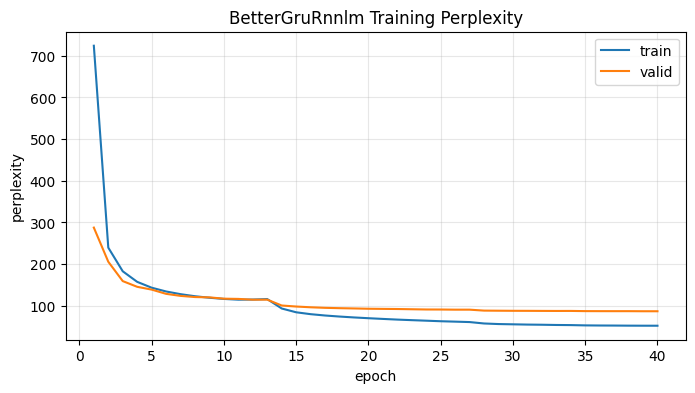

In [14]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(val_ppl_list) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_ppl_list, label="train")
plt.plot(epochs, val_ppl_list, label="valid")
plt.title("BetterGruRnnlm Training Perplexity")
plt.xlabel("epoch")
plt.ylabel("perplexity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 结果反思：说明

这一节的重点是确认你是否理解 BetterGruRnnlm 相比 Rnnlm 的变化，以及最终实验中验证集和学习率衰减的作用。

建议记录：

- 两层 GRU 对模型表达能力和计算成本的影响
- Dropout 为什么放在深度方向
- 权重共享为什么要求 `wordvec_size == hidden_size`
- validation perplexity 变差时为什么降低学习率
- smoke 配置和 full 配置的结果差异
